#Logistic Regression

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, recall_score, accuracy_score
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
model_results = {
    'FPR0': [], 'TPR0': [], 'FPR1': [], 'TPR1': [],
    'ACC': [], 'Recall': [], 'Precision': [], 'F1': []
}


def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    Plot the confusion matrix with improved visualization.

    Args:
        cm (array): Confusion matrix
        classes (list): Class labels
        title (str): Title for the plot
        cmap: Colormap for the plot
    """
    plt.figure(figsize=(8, 6))
    plt.grid(False)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment="center",
                fontsize=12,
                color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    plt.show()


def perform_cross_validation(model, k, x, y, scoring='accuracy'):
    """
    Perform cross validation with improved output format.

    Args:
        model: Machine learning model
        k (int): Number of folds
        x (DataFrame/array): Features
        y (DataFrame/array): Target
        scoring (str): Evaluation metric

    Returns:
        float: Mean cross-validation score
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, x, y, cv=kf, scoring=scoring)
    cv_mean = np.mean(cv_results)

    print(f"Cross-Validation Results (k={k}, scoring={scoring})")
    print(f"Mean: {cv_mean:.4f}")
    print(f"Std Dev: {np.std(cv_results):.4f}")
    print(f"Min: {np.min(cv_results):.4f}, Max: {np.max(cv_results):.4f}")
    print(f"All scores: {cv_results}\n")

    return cv_mean


def plot_feature_importance(model, x_test):
    """
    Plot feature importance with improved visualization.

    Args:
        model: Trained model with feature coefficients
        x_test (DataFrame): Test features

    Returns:
        DataFrame: Features importance data
    """
    coeff = list(model.coef_[0])
    labels = list(x_test.columns)
    features = pd.DataFrame()
    features['Features'] = labels + ['Intercept']
    features['Importance'] = coeff + [model.intercept_[0]]
    features.sort_values(by=['Importance'], ascending=True, inplace=True)
    features['Positive'] = features['Importance'] > 0
    features.set_index('Features', inplace=True)

    plt.figure(figsize=(10, 6))
    features.Importance.plot(kind='barh',
                             color=features.Positive.map({True: '#2ecc71', False: '#e74c3c'}))
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.title('Feature Importance', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return features


def plot_model_results(results):
    """
    Plot comprehensive model evaluation results.

    Args:
        results (dict): Dictionary containing model metrics
    """
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Model Evaluation Results', fontsize=16, fontweight='bold', y=1.05)

    metrics_df = pd.DataFrame({
        'Accuracy': results['ACC'],
        'Recall': results['Recall'],
        'Precision': results['Precision'],
        'F1 Score': results['F1']
    })

    sns.lineplot(data=metrics_df, markers=True, ax=axs[0], palette='viridis')
    axs[0].set_xlabel('Model Index', fontsize=12)
    axs[0].set_ylabel('Score', fontsize=12)
    axs[0].set_title('Performance Metrics', fontsize=14)
    axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                  fancybox=True, shadow=True, ncol=4)
    axs[0].grid(alpha=0.3)

    axs[1].set_title('ROC Curve - Class 1', fontsize=14)
    for i, (fpr, tpr) in enumerate(zip(results['FPR1'], results['TPR1']), 1):
        auc_score = metrics.auc(fpr, tpr)
        axs[1].plot(fpr, tpr, label=f"Model {i} (AUC = {auc_score:.3f})")

    axs[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axs[1].set_xlabel('False Positive Rate', fontsize=12)
    axs[1].set_ylabel('True Positive Rate', fontsize=12)
    axs[1].legend(loc='lower right')
    axs[1].grid(alpha=0.3)

    axs[2].set_title('ROC Curve - Class 0', fontsize=14)
    for i, (fpr, tpr) in enumerate(zip(results['FPR0'], results['TPR0']), 1):
        auc_score = metrics.auc(fpr, tpr)
        axs[2].plot(fpr, tpr, '--', label=f"Model {i} (AUC = {auc_score:.3f})")

    axs[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axs[2].set_xlabel('False Positive Rate', fontsize=12)
    axs[2].set_ylabel('True Positive Rate', fontsize=12)
    axs[2].legend(loc='lower right')
    axs[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def train_and_evaluate_model(x, y, test_size=0.2, classes=None, parameters=None, store_results=True):
    """
    Complete pipeline to train and evaluate a logistic regression model.

    Args:
        x (DataFrame): Features
        y (Series): Target
        test_size (float): Test set proportion
        classes (list): Class labels
        parameters (dict): Model hyperparameters
        store_results (bool): Whether to store results in global lists

    Returns:
        tuple: (trained_model, accuracy, feature_importance)
    """
    if classes is None:
        classes = ['Class 1', 'Class 0']

    if parameters is None:
        parameters = {'solver': 'liblinear', 'penalty': 'l2', 'C': 1.0}

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=test_size, random_state=42, stratify=y
    )

    logreg = LogisticRegression(
        solver=parameters.get('solver'),
        penalty=parameters.get('penalty'),
        C=parameters.get('C'),
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    )

    logreg.fit(x_train, y_train)

    y_pred = logreg.predict(x_test)
    y_pred_proba = logreg.predict_proba(x_test)

    cm = confusion_matrix(y_test, y_pred)
    fpr1, tpr1, _ = roc_curve(y_test, y_pred_proba[:,1])
    fpr0, tpr0, _ = roc_curve(y_test, y_pred_proba[:,0])

    acc = metrics.accuracy_score(y_test, y_pred)
    rec = metrics.recall_score(y_test, y_pred)
    pre = metrics.precision_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)

    if store_results:
        model_results['FPR0'].append(fpr0)
        model_results['TPR0'].append(tpr0)
        model_results['FPR1'].append(fpr1)
        model_results['TPR1'].append(tpr1)
        model_results['ACC'].append(acc)
        model_results['Recall'].append(rec)
        model_results['Precision'].append(pre)
        model_results['F1'].append(f1)

    plot_model_results(model_results)

    print(f"\n{'='*20} Model Evaluation Results {'='*20}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Jaccard Score: {metrics.jaccard_score(y_test, y_pred):.4f}\n")

    print(f"{'='*20} Confusion Matrix {'='*20}")
    print(cm)
    plot_confusion_matrix(cm, classes, cmap=plt.cm.Blues)

    print(f"{'='*20} Classification Report {'='*20}")
    print(classification_report(y_test, y_pred, target_names=classes))

    feature_imp = plot_feature_importance(logreg, x_test)

    return logreg, acc, feature_imp


def perform_grid_search(x_train, y_train, param_grid=None, cv=10):
    """
    Perform grid search for hyperparameter tuning.

    Args:
        x_train: Training features
        y_train: Training target
        param_grid (dict): Grid of parameters
        cv (int): Number of cross-validation folds

    Returns:
        dict: Best parameters
    """
    if param_grid is None:
        param_grid = {
            'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
            'penalty': ['l2'],
            'C': [100, 10, 1.0, 0.1, 0.01],
            'class_weight': [None, 'balanced']
        }

    model = LogisticRegression(max_iter=1000, random_state=42)
    cv_strategy = RepeatedStratifiedKFold(n_splits=cv, n_repeats=3, random_state=42)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring='accuracy',
        n_jobs=-1,
        error_score=0,
        verbose=1
    )

    print(f"Starting grid search with {len(param_grid['solver']) * len(param_grid['penalty']) * len(param_grid['C'])} combinations...")
    grid_result = grid_search.fit(x_train, y_train)

    print(f"\nBest Score: {grid_result.best_score_:.4f}")
    print(f"Best Parameters: {grid_result.best_params_}")

    results_df = pd.DataFrame(grid_result.cv_results_)
    results_df = results_df.sort_values(by='rank_test_score')

    plt.figure(figsize=(12, 8))

    top_results = results_df.head(10)
    params = [str(p) for p in top_results['params']]
    short_params = [f"C={p['C']}, solver={p['solver']}" for p in top_results['params']]

    plt.barh(range(len(short_params)), top_results['mean_test_score'], xerr=top_results['std_test_score'],
             align='center', color='skyblue', ecolor='black', capsize=5)
    plt.yticks(range(len(short_params)), short_params)
    plt.xlabel('Accuracy Score')
    plt.title('Grid Search Results (Top 10 Combinations)', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return grid_result.best_params_

In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
df = pd.read_csv("diabetes.csv", header=None, names=col_names)

In [4]:
df

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.63,50,1
1,1,85,66,29,0,26.6,0.35,31,0
2,8,183,64,0,0,23.3,0.67,32,1
3,1,89,66,23,94,28.1,0.17,21,0
4,0,137,40,35,168,43.1,2.29,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.17,63,0
764,2,122,70,27,0,36.8,0.34,27,0
765,5,121,72,23,112,26.2,0.25,30,0
766,1,126,60,0,0,30.1,0.35,47,1


In [5]:
df['label'].value_counts()

,count
label,
0,500
1,268


In [6]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

X = pd.DataFrame(X_norm, index=X.index, columns=X.columns)

## Keypoints (How to approach the problem?)
1. Understand the dataset
2. Handle Imbalanced classes
2. Choose the correct metric for evaluation



###Handle Imbalanced Classes

1.   Resampling Techniques
*   Oversampling - Duplicate or synthetically create examples of the minority
*   Undersampling - Remove some examples from the majority class to balance the dataset
2.   Use Class Weight Parameter
3.   Use different evaluation metrics. Avoid accuracy!







In [7]:
print("Length of X:", len(X))
print("Length of y:", len(y))

print(df['label'].value_counts())

Length of X: 768
Length of y: 768
label
0    500
1    268
Name: count, dtype: int64


In [8]:
#Oversampling

from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE().fit_resample(X, y)

print("Length of X:", len(X_res))
print("Length of y:", len(y_res))
print(y_res.value_counts())

Length of X: 1000
Length of y: 1000
label
1    500
0    500
Name: count, dtype: int64


In [9]:
#Undersampling

from imblearn.under_sampling import RandomUnderSampler
X_res, y_res = RandomUnderSampler().fit_resample(X, y)

print("Length of X:", len(X_res))
print("Length of y:", len(y_res))
print(y_res.value_counts())

Length of X: 536
Length of y: 536
label
0    268
1    268
Name: count, dtype: int64


###Important: When are metrics other than accuracy needed?

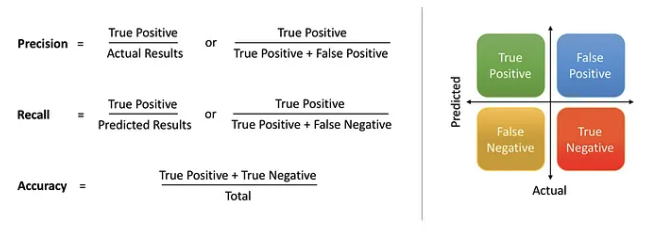



In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [11]:
logreg = LogisticRegression(solver='liblinear', random_state=42)
cross5_acc = perform_cross_validation(logreg, 5, X_train, y_train)
cross10_acc = perform_cross_validation(logreg, 10, X_train, y_train)

Cross-Validation Results (k=5, scoring=accuracy)
Mean: 0.7569
Std Dev: 0.0336
Min: 0.7217, Max: 0.8174
All scores: [0.76724138 0.73913043 0.8173913  0.72173913 0.73913043]

Cross-Validation Results (k=10, scoring=accuracy)
Mean: 0.7568
Std Dev: 0.0497
Min: 0.6897, Max: 0.8621
All scores: [0.82758621 0.68965517 0.75862069 0.74137931 0.75862069 0.86206897
 0.73684211 0.70175439 0.73684211 0.75438596]



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


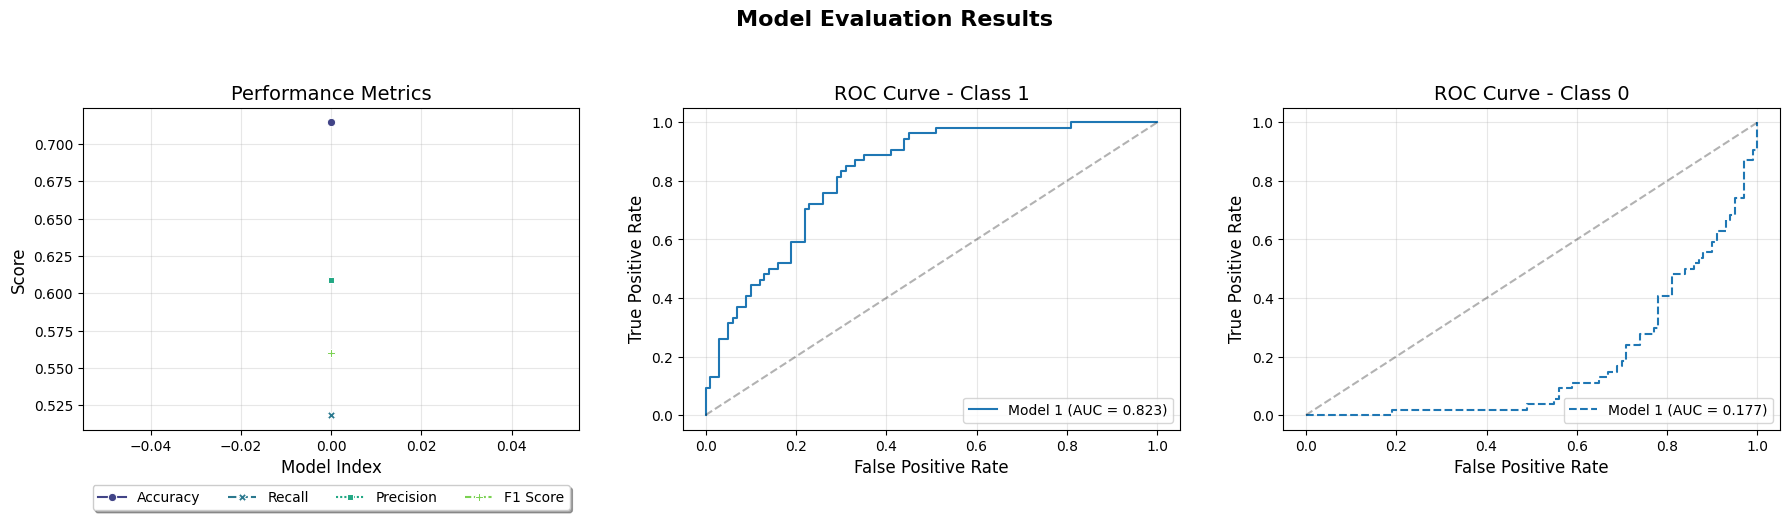


==================== Model Evaluation Results ====================
Accuracy: 0.7143
Recall: 0.5185
Precision: 0.6087
F1 Score: 0.5600
Jaccard Score: 0.3889

==================== Confusion Matrix ====================
[[82 18]
 [26 28]]


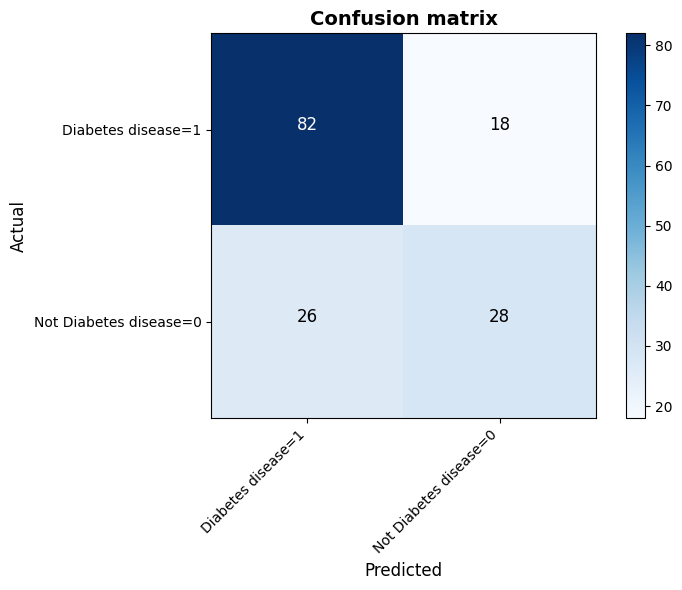

==================== Classification Report ====================
                        precision    recall  f1-score   support

    Diabetes disease=1       0.76      0.82      0.79       100
Not Diabetes disease=0       0.61      0.52      0.56        54

              accuracy                           0.71       154
             macro avg       0.68      0.67      0.67       154
          weighted avg       0.71      0.71      0.71       154



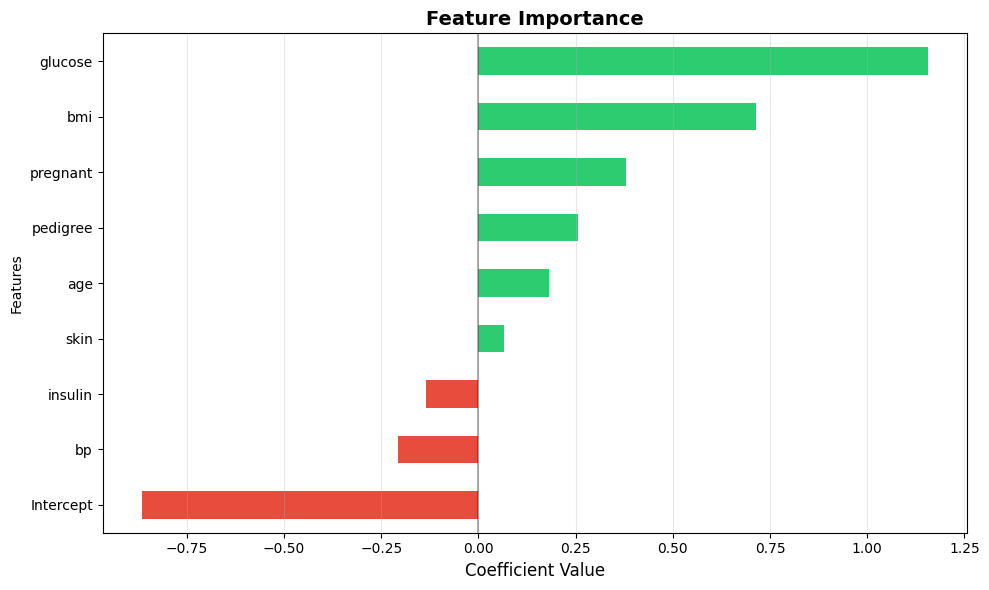

In [12]:
parameters = {'solver': 'liblinear', 'penalty': 'l2', 'C': 1.0}

model, acc, features = train_and_evaluate_model(
    X, y, 0.2,
    ['Diabetes disease=1', 'Not Diabetes disease=0'],
    parameters
)

Starting grid search with 25 combinations...
Fitting 30 folds for each of 50 candidates, totalling 1500 fits

Best Score: 0.7639
Best Parameters: {'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}


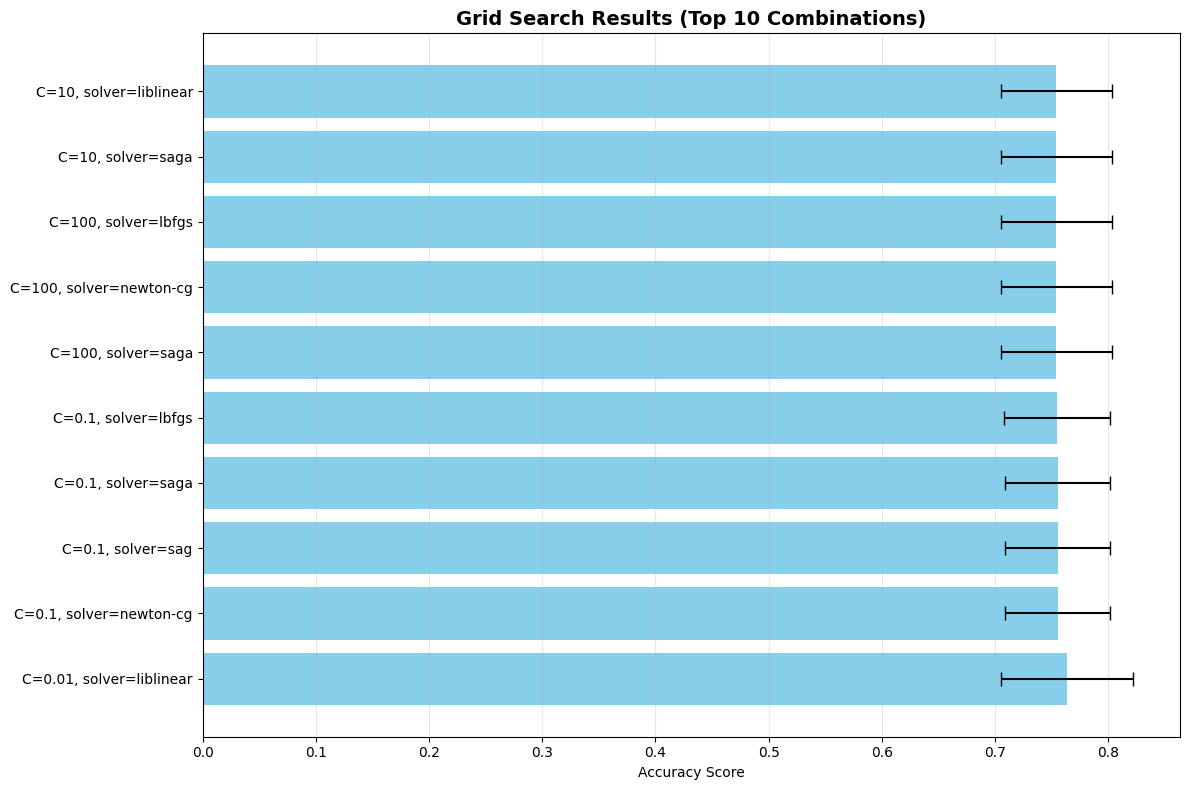

In [13]:
best_params = perform_grid_search(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


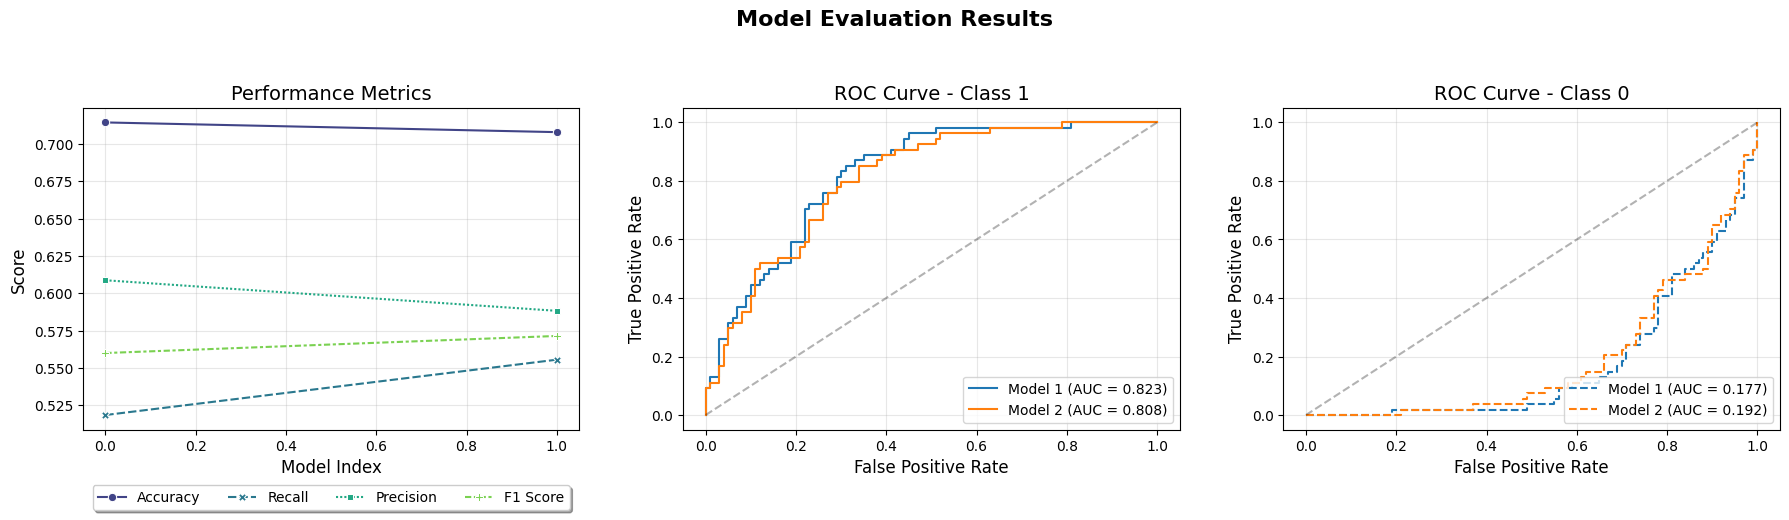


==================== Model Evaluation Results ====================
Accuracy: 0.7078
Recall: 0.5556
Precision: 0.5882
F1 Score: 0.5714
Jaccard Score: 0.4000

==================== Confusion Matrix ====================
[[79 21]
 [24 30]]


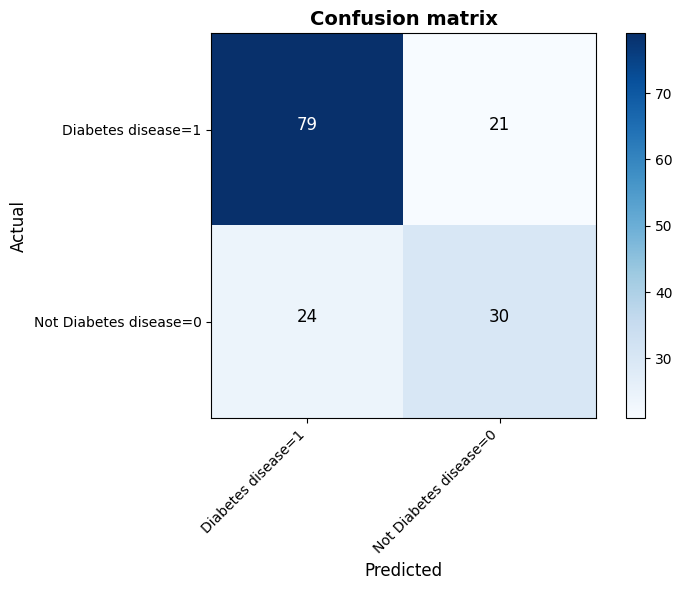

==================== Classification Report ====================
                        precision    recall  f1-score   support

    Diabetes disease=1       0.77      0.79      0.78       100
Not Diabetes disease=0       0.59      0.56      0.57        54

              accuracy                           0.71       154
             macro avg       0.68      0.67      0.67       154
          weighted avg       0.70      0.71      0.71       154



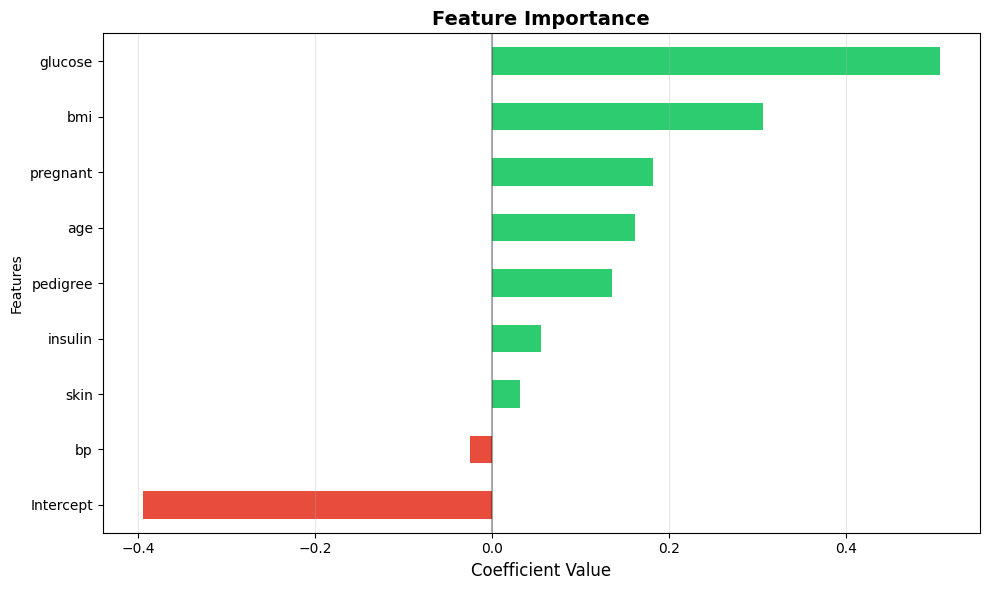

In [14]:
model, _, features = train_and_evaluate_model(
    X, y, 0.2,
    ['Diabetes disease=1', 'Not Diabetes disease=0'],
    best_params
)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


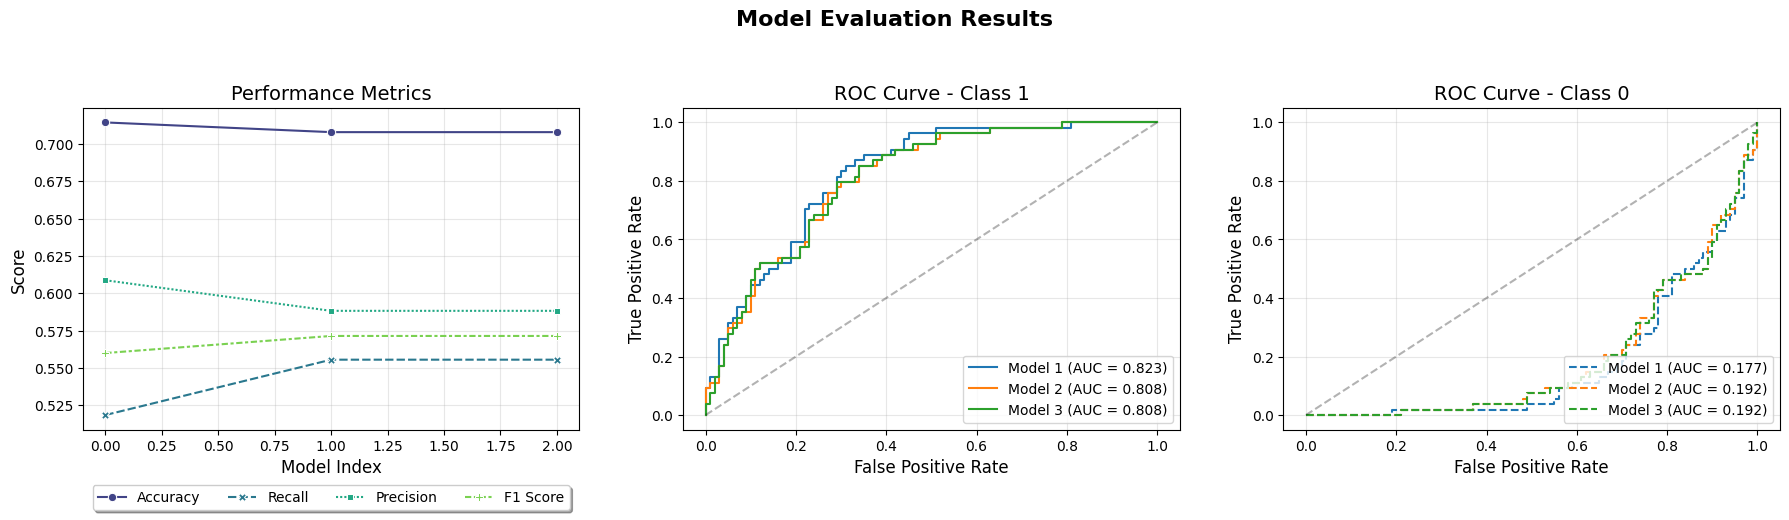


==================== Model Evaluation Results ====================
Accuracy: 0.7078
Recall: 0.5556
Precision: 0.5882
F1 Score: 0.5714
Jaccard Score: 0.4000

==================== Confusion Matrix ====================
[[79 21]
 [24 30]]


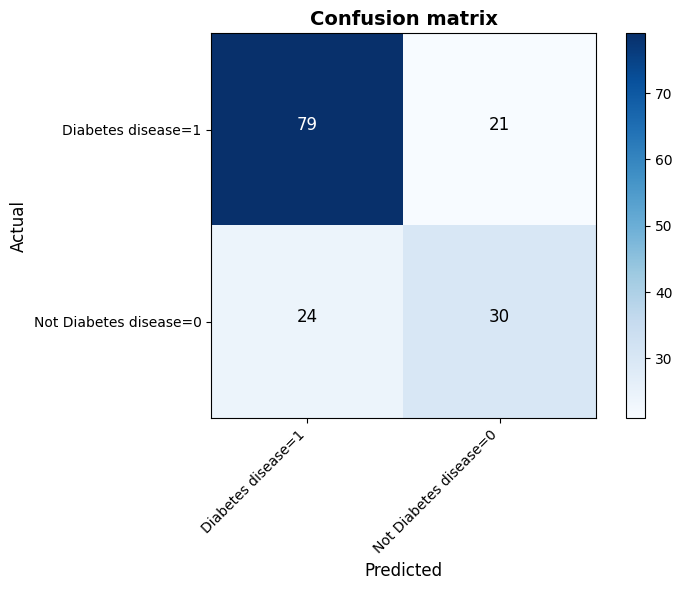

==================== Classification Report ====================
                        precision    recall  f1-score   support

    Diabetes disease=1       0.77      0.79      0.78       100
Not Diabetes disease=0       0.59      0.56      0.57        54

              accuracy                           0.71       154
             macro avg       0.68      0.67      0.67       154
          weighted avg       0.70      0.71      0.71       154



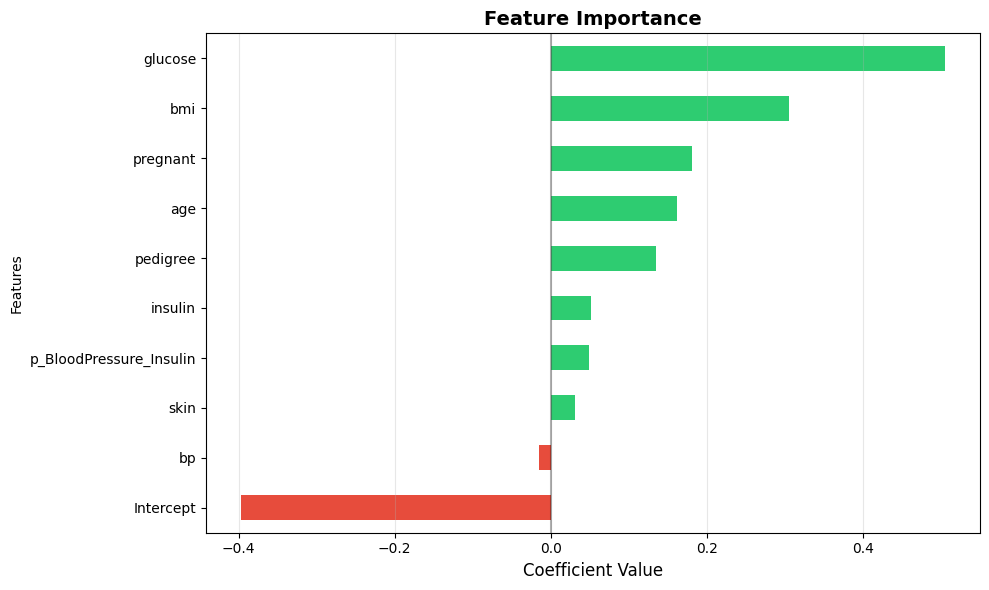

In [15]:
X['p_BloodPressure_Insulin'] = X.bp * X.insulin
model, _, features = train_and_evaluate_model(
    X, y, 0.2,
    ['Diabetes disease=1', 'Not Diabetes disease=0'],
    best_params
)

In [16]:
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
proba_class_1 = y_pred_proba[:, 1]

# Custom threshold = 0.3
y_pred_custom = (proba_class_1 > 0.3).astype(int)
print("Confusion Matrix (threshold=0.3):")
print(confusion_matrix(y_test, y_pred_custom))
print("\nRecall (threshold=0.3):", recall_score(y_test, y_pred_custom))
print("Accuracy (threshold=0.3):", accuracy_score(y_test, y_pred_custom))

# Default threshold = 0.5
y_pred_default = model.predict(X_test)
print("\nConfusion Matrix (default threshold=0.5):")
print(confusion_matrix(y_test, y_pred_default))
print("\nRecall (default threshold=0.5):", recall_score(y_test, y_pred_default))
print("Accuracy (default threshold=0.5):", accuracy_score(y_test, y_pred_default))


Confusion Matrix (threshold=0.3):
[[56 74]
 [ 1 61]]

Recall (threshold=0.3): 0.9838709677419355
Accuracy (threshold=0.3): 0.609375

Confusion Matrix (default threshold=0.5):
[[111  19]
 [ 28  34]]

Recall (default threshold=0.5): 0.5483870967741935
Accuracy (default threshold=0.5): 0.7552083333333334


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


# Now the goal is to train a Ridge Logistic Regression model (using a MAP point estimate for the coefficients w of the model), as well as a ensemble of Logistic Regression models (using a Monte-Carlo Approximation, where we use the whole posterior distribution of the coefficients w of the model) and see the differences and advantages/disadvantages of the different approaches

## Import the required libraries

In [17]:
import warnings
warnings.filterwarnings("ignore")
from scipy import linalg
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
%matplotlib notebook
# plt.rcParams['figure.dpi'] = 120

## Functions for generating the data, visualization and calculating the Hessian  

In [18]:
# Colormap
cmap = colors.LinearSegmentedColormap(
    'red_blue_classes',
    {'red': [(0, 1, 1), (1, 0.7, 0.7)],
     'green': [(0, 0.7, 0.7), (1, 0.7, 0.7)],
     'blue': [(0, 0.7, 0.7), (1, 1, 1)]})
mpl.colormaps.register(cmap)

# Data Generating function (generates N samples in each class with D dimensions)
def dataset_fixed_cov(N = 100, D = 2):
    '''Generate 2 Gaussians samples with the same covariance matrix'''
    np.random.seed(0) #Fix random seed so each time we get the same distribution, if we don't want that just comment this line
    C = np.array([[0., -0.23], [0.83, .23]]) #Covariance matrix
    X = np.r_[np.dot(np.random.randn(N, D), C), #Generate N samples in the class 0 with mean [0,0]
              np.dot(np.random.randn(N, D), C) + np.array([1, 1])] #Generate N samples in the class 0 with mean [1,1]
    y = np.hstack((np.zeros(N), np.ones(N))) #The classes of the data, first N samples are in the class 0, the rest are in the class 1
    return X, y

#Data plotting function
def plot_data(X, y):
    plt.figure()
    X0, X1 = X[y == 0], X[y == 1] #Divide the data based on the class

    # Scatterplot of class 0 in red
    plt.scatter(X0[:, 0], X0[:, 1], marker='.', color='red')

    # Scatterplot of class 1 in blue
    plt.scatter(X1[:, 0], X1[:, 1], marker='.', color='blue')

    # Scatterplot of two values we want to predict
    plt.scatter(2, 0.5, marker="*", color = "black")
    plt.scatter(3, 0.5, marker="*", color = "black")

#Plotting function of data and the Logistic Regression decision function for a specific classifier
def plot_LR_data(LR, X, y, y_pred):

    tp = (y == y_pred)
    tp0, tp1 = tp[y == 0], tp[y == 1]
    X0, X1 = X[y == 0], X[y == 1]
    X0_tp, X0_fp = X0[tp0], X0[~tp0] #We get the true and false negatives based on our LR classifier
    X1_tp, X1_fp = X1[tp1], X1[~tp1] #We get the true and false positives based on our LR classifier

    # Scatterplot of class 0 in red, as well as the False negatives as crosses (x)
    plt.scatter(X0_tp[:, 0], X0_tp[:, 1], marker='.', color='red')
    plt.scatter(X0_fp[:, 0], X0_fp[:, 1], marker='x',
                s=20, color='#990000')  # dark red

    # Scatterplot of class 1 in blue, as well as the False positives as crosses (x)
    plt.scatter(X1_tp[:, 0], X1_tp[:, 1], marker='.', color='blue')
    plt.scatter(X1_fp[:, 0], X1_fp[:, 1], marker='x',
                s=20, color='#000099')  # dark blue

    # Scatterplot of two values we want to predict
    plt.scatter(2, 0.5, marker="*", color = "black")
    plt.scatter(3, 0.5, marker="*", color = "black")

    # Areas of the two classes based on the decision function of our model
    nx, ny = 200, 100
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                         np.linspace(y_min, y_max, ny))
    Z = LR.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z[:, 1].reshape(xx.shape)
    plt.pcolormesh(xx, yy, Z, cmap='red_blue_classes',
                   norm=colors.Normalize(0., 1.), zorder=0)
    plt.contour(xx, yy, Z, [0.5], linewidths=2., colors='darkgreen') #The decision function of our model

#Plotting function of data and and ensemble of Logistic Regression decision function for a specific classifier
def plot_LR_data_bayes(LRmodels, X, y):

    X0, X1 = X[y == 0], X[y == 1]

    # Scatterplot of class 0 in red
    plt.scatter(X0[:, 0], X0[:, 1], marker='.', color='red')

    # Scatterplot of class 1 in blue
    plt.scatter(X1[:, 0], X1[:, 1], marker='.', color='blue')

    # Scatterplot of two values we want to predict
    plt.scatter(2, 0.5, marker="*", color = "black")
    plt.scatter(3, 0.5, marker="*", color = "black")

    #We draw the decision function as well as the areas of the two classes based on each model in the ensemble
    for LR in LRmodels:
        # Areas of the two classes based on the decision function of each model
        nx, ny = 200, 100
        x_min, x_max = plt.xlim()
        y_min, y_max = plt.ylim()
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                             np.linspace(y_min, y_max, ny))
        Z = LR.predict_proba(np.c_[xx.ravel(), yy.ravel()])
        Z = Z[:, 1].reshape(xx.shape)
        plt.pcolormesh(xx, yy, Z, cmap='red_blue_classes',
                       norm=colors.Normalize(0., 1.), zorder=0)
        plt.contour(xx, yy, Z, [0.5], linewidths=2., colors='darkgreen', alpha = 0.3) #The decision function for each model in the ensemble

In [19]:
def phi(t):
    # logistic function, returns 1 / (1 + exp(-t))
    idx = t > 0
    out = np.empty(t.size, dtype=np.float64)
    out[idx] = 1. / (1 + np.exp(-t[idx]))
    exp_t = np.exp(t[~idx])
    out[~idx] = exp_t / (1. + exp_t)
    return out

def loss(w, X, y, alpha):
    # logistic loss function, returns Sum{-log(phi(t))}
    z = X.dot(w)
    yz = y * z
    idx = yz > 0
    out = np.zeros_like(yz)
    out[idx] = np.log(1 + np.exp(-yz[idx]))
    out[~idx] = (-yz[~idx] + np.log(1 + np.exp(yz[~idx])))
    out = out.sum() + .5 * alpha * w.dot(w)
    return out

def gradient(w, X, y, alpha):
    # gradient of the logistic loss
    z = X.dot(w)
    z = phi(y * z)
    z0 = (z - 1) * y
    grad = X.T.dot(z0) + alpha * w
    return grad

#This is the important function
def hessian(w, X, y, s, alpha):
    # hessian of the logistic loss
    z = X.dot(w)
    z = phi(y * z)
    d = z * (1 - z)
    d = np.diag(d).shape
    wa = d * X.dot(s)
    Hs = X.T.dot(wa)
    out = Hs + alpha * s
    return  out

## Generate the data

### We generate data for the two classes. The goal is to make predictions for the points x1=[2,0.5] and x2=[3,0.5] which are shown in the scatterplot below with a *

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

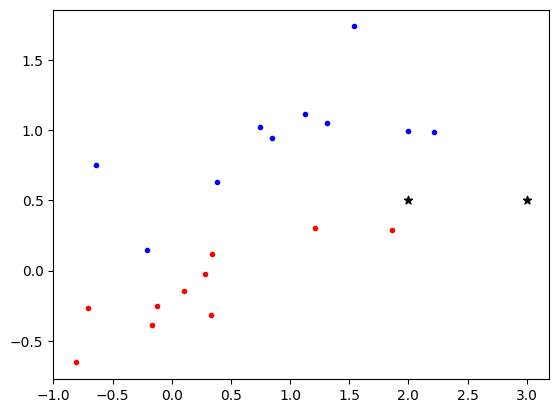

In [29]:
#Generate and plot the data
X,y = dataset_fixed_cov(10, 2)
plot_data(X,y)

## Initialize lists which will contain all of the Logistic Regression Models of the ensemble, the coefficients and the predictions for the points x_1=[2,0.5] and x_2[3,0.5]

In [30]:
Number_of_predictors = 100 #The number of logistic regression models we want in the ensemble (Higher number of predictors will be more computationally expensive but have better results)

LR_predictors = np.zeros(Number_of_predictors, dtype=object) #Initialize a list containing the ensemble of Logistic Regression Models
LR_coefficient1 = np.zeros(Number_of_predictors+1) #Initialize a list containing the w1 coefficients of the ensemble of Logistic Regression Models
LR_coefficient2 = np.zeros(Number_of_predictors+1) #Initialize a list containing the w2 coefficients of the ensemble of Logistic Regression Models

PosPrediction_probabilities = np.zeros(Number_of_predictors+1) #Initialize a list containing the probabilities p(y=1|x), for x=[2,0.5] of the Logistic Regression Models
NegPrediction_probabilities = np.zeros(Number_of_predictors+1) #Initialize a list containing the probabilities p(y=0|x), for x=[2,0.5] of the Logistic Regression Models

PosPrediction_probabilities2 = np.zeros(Number_of_predictors+1) #Initialize a list containing the probabilities p(y=1|x), for x=[3,0.5] of the Logistic Regression Models
NegPrediction_probabilities2 = np.zeros(Number_of_predictors+1) #Initialize a list containing the probabilities p(y=0|x), for x=[3,0.5] of the Logistic Regression Models

## Train (Fit) the Ridge Logistic Regression model and visualize the results

### We first train only one standard Ridge Logistic Regression model - with a MAP point estimate of the coefficients w

Ridge Logistic Regression accuracy for the dataset 0.95
MAP Logistic Regression predictor coefficients: [[0.09983831 1.99399754]]
MAP Logistic Regression predictor intercept: [-0.84012179]
Ridge Logistic Regression predictor probability prediction of point [2,0.5]: 0.41179409773931686
Ridge Logistic Regression predictor probability prediction of point [3,0.5]: 0.38784211169603733


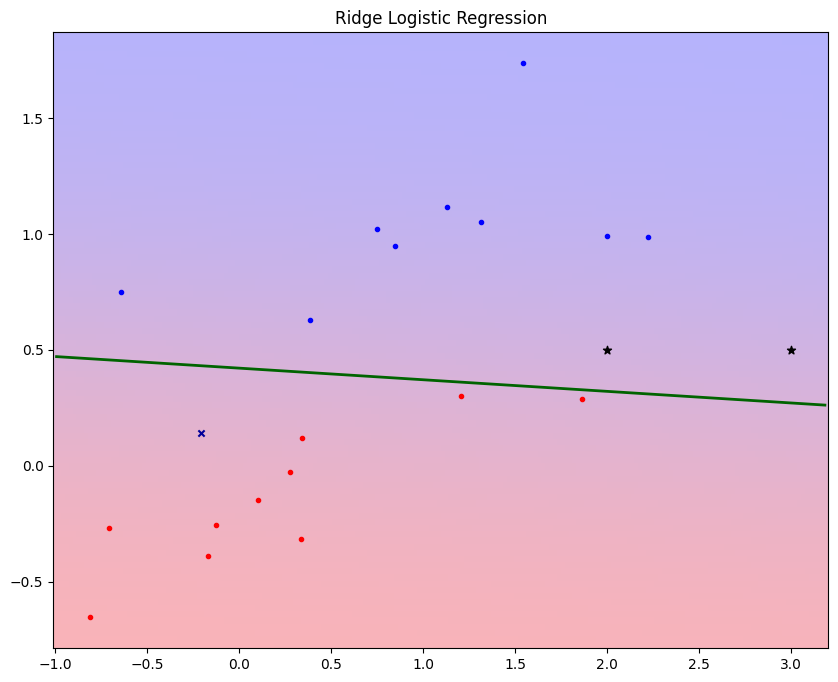

In [38]:
LR = LogisticRegression(penalty='l2', C=1) #Initialize the original Logistic Regression model

y_pred = LR.fit(X, y).predict(X) #Predictions for X

w1_MAP = LR.coef_[0][0] #The w1 MAP estimate for the first feature
w2_MAP = LR.coef_[0][1] #The w2 MAP estimate for the second feature
w0 = LR.intercept_[0]

Hessian = hessian(LR.coef_[0], X, y, np.identity(len(LR.coef_[0])), 1) #The Hessian (2nd derivative) at point w_MAP
Hessian_Inv = np.linalg.inv(Hessian) #The inverse of the Hessian which we will use as the covariance matrix for the coefficient prior

print("Ridge Logistic Regression accuracy for the dataset", np.sum(y == y_pred)/len(y))
print("MAP Logistic Regression predictor coefficients:", LR.coef_)
print("MAP Logistic Regression predictor intercept:", LR.intercept_)
print("Ridge Logistic Regression predictor probability prediction of point [2,0.5]:",
      LR.predict_proba([[2, 0.5]])[0][0])
print("Ridge Logistic Regression predictor probability prediction of point [3,0.5]:",
      LR.predict_proba([[3, 0.5]])[0][0])

plt.figure(figsize=(10, 8), facecolor='white')
plt.title("Ridge Logistic Regression")
plot_LR_data(LR, X, y, y_pred)
plt.axis('tight')

LR_coefficient1[0] = w1_MAP #We add the MAP w1 coefficient to the w1 coefficient list
LR_coefficient2[0] = w2_MAP #We add the MAP w2 coefficient to the w1 coefficient list

#We add the Ridge Logistic Regression prediction probabilities to the appropriate lists
PosPrediction_probabilities[0] = LR.predict_proba([[2, 0.5]])[0][0]
NegPrediction_probabilities[0] = LR.predict_proba([[2, 0.5]])[0][1]

PosPrediction_probabilities2[0] = LR.predict_proba([[3, 0.5]])[0][0]
NegPrediction_probabilities2[0] = LR.predict_proba([[3, 0.5]])[0][1]

# Fit all of the other Logistic Regression models of the ensemble using Monte Carlo Approximation of the coefficients and visualize the results

### Now we train an ensemble of Logistic Regression models - with coefficients w sampled from the posterior distribution N(w_MAP, Hessian_Inverse) - Slide 10 - AV7.
### Using this ensemble we can also approximate the posterior predictive distribution for the points x1,x2 as we will see below.

### During the lecture, we used a identity matrix as the covariance matrix of the posterior distribution of the coefficients which led to a lot of wrong estimations of the decision function and larger predictive probability distribution. Here we use a Gaussian Approximation of the posterior distribution, using the inverse of the Hessian as the covariance matrix, leading to a way better model.

Linear Regression predictor 0 coefficients: [[0.12103286 1.85494383]]
Linear Regression predictor 0 accuracy for the dataset 0.95
Linear Regression predictor 0 probability prediction of point [2,0.5]: 0.41838276167252375
Linear Regression predictor 1 coefficients: [[0.27911896 1.86078056]]
Linear Regression predictor 1 accuracy for the dataset 0.85
Linear Regression predictor 1 probability prediction of point [2,0.5]: 0.34332619482129356
Linear Regression predictor 2 coefficients: [[0.11870647 1.9319159 ]]
Linear Regression predictor 2 accuracy for the dataset 0.95
Linear Regression predictor 2 probability prediction of point [2,0.5]: 0.410173278392714
Linear Regression predictor 3 coefficients: [[0.20922281 1.88188594]]
Linear Regression predictor 3 accuracy for the dataset 0.9
Linear Regression predictor 3 probability prediction of point [2,0.5]: 0.37302369575357386


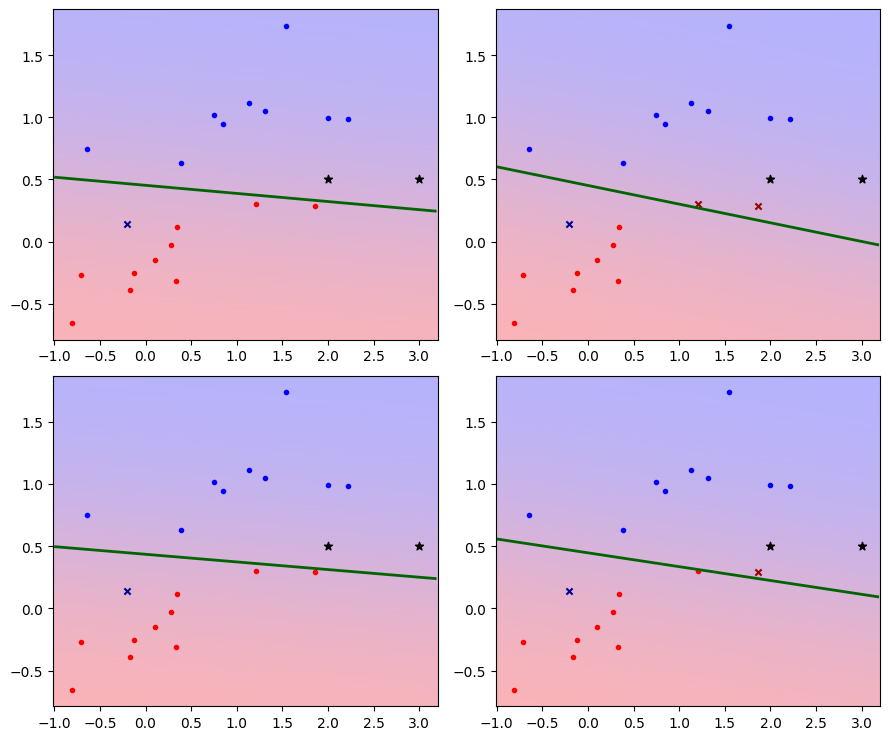

In [32]:
plt.figure(figsize=(9, 8), facecolor='white')
#For each model of the ensemble
for j in range(Number_of_predictors):
    LR_predictors[j] = LogisticRegression().fit(X,y) #We first need to fit the model on the data

    #We sample the coefficients from a 2D normal distribution with the MAP estimates of
    #the coefficients as the mean of the distribution and the inverse of the Hessian as the covariance matrix of the distribution
    #These will be the new coefficients of the j-th model of the ensemble
    w1_s, w2_s = np.random.multivariate_normal(LR.coef_[0], Hessian_Inv, 1).T

    LR_coefficient1[j+1] = w1_s #We add the new sampled w1 coefficients to the w1 coefficient list
    LR_coefficient2[j+1] = w2_s #We add the new sampled w2 coefficients to the w2 coefficient list

    LR_predictors[j].coef_[0][0] = w1_s #We set the new sampled w1 coefficient as the w1 coefficient of the j-th model of the ensemble
    LR_predictors[j].coef_[0][1] = w2_s #We set the new sampled w2 coefficient as the w2 coefficient of the j-th model of the ensemble
    LR_predictors[j].intercept_ = LR.intercept_ #We use the same intercept as in the Ridge Logistic Regression model for every model of the ensemble

    #We add the prediction probabilities of the j-th Logistic Regression model to the appropriate lists

    PosPrediction_probabilities[j+1] = LR_predictors[j].predict_proba([[2, 0.5]])[0][0]
    NegPrediction_probabilities[j+1] = LR_predictors[j].predict_proba([[2, 0.5]])[0][1]

    PosPrediction_probabilities2[j+1] = LR_predictors[j].predict_proba([[3, 0.5]])[0][0]
    NegPrediction_probabilities2[j+1] = LR_predictors[j].predict_proba([[3, 0.5]])[0][1]

    #We only visualize the first 4 Logistic Regression model results
    if(j<4):
        print("Linear Regression predictor " + str(j)+" coefficients:", LR_predictors[j].coef_)
        y_pred_bayes = LR_predictors[j].predict(X)
        print("Linear Regression predictor " + str(j) + " accuracy for the dataset", np.sum(y == y_pred_bayes)/len(y))
        plt.subplot(2,2,j+1)
        plot_LR_data(LR_predictors[j], X, y, y_pred_bayes)
        print("Linear Regression predictor " + str(j) + " probability prediction of point [2,0.5]:",
              LR_predictors[j].predict_proba([[2, 0.5]])[0][0])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

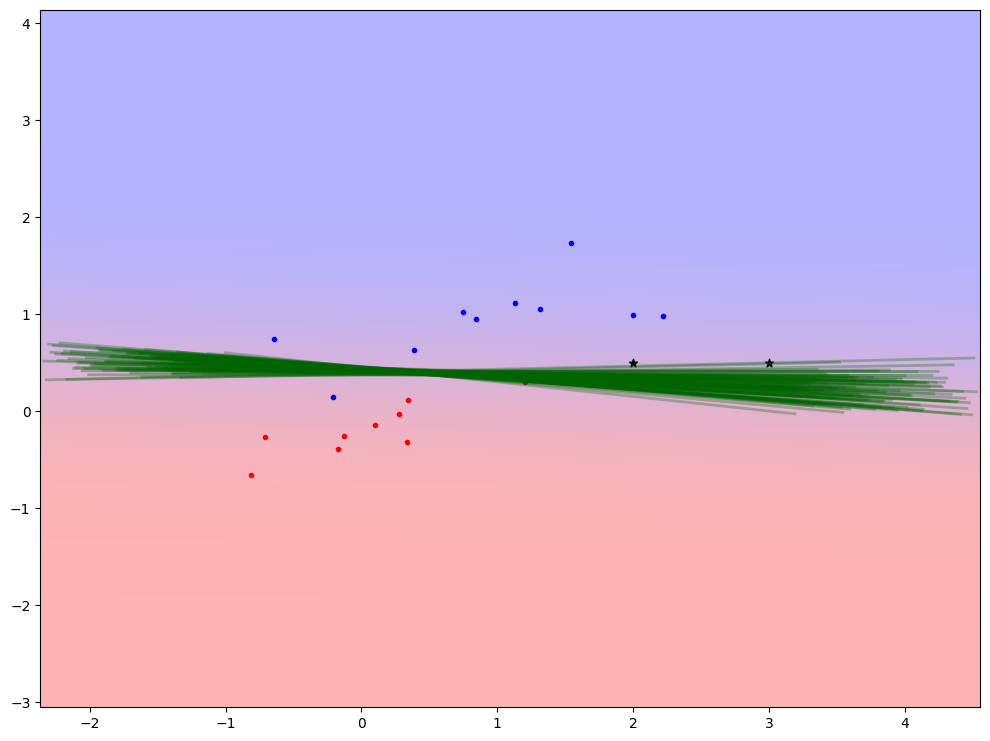

In [33]:
#We plot the decision functions of each Logistic Regression model in one figure
plt.figure(figsize=(10, 8), facecolor='white')
plot_LR_data_bayes(LR_predictors,X,y)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

### We visualize the distribution of the coefficients of our ensemble as well as the MAP point estimate of the coefficients.

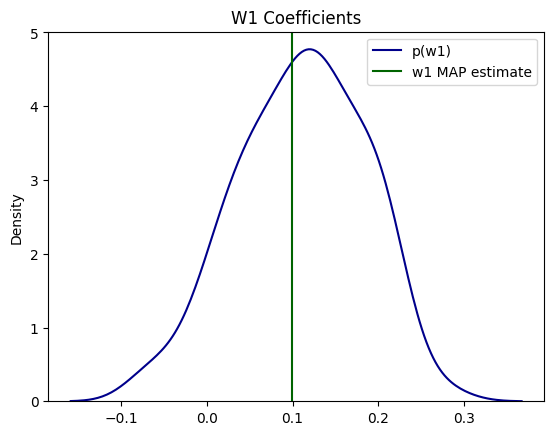

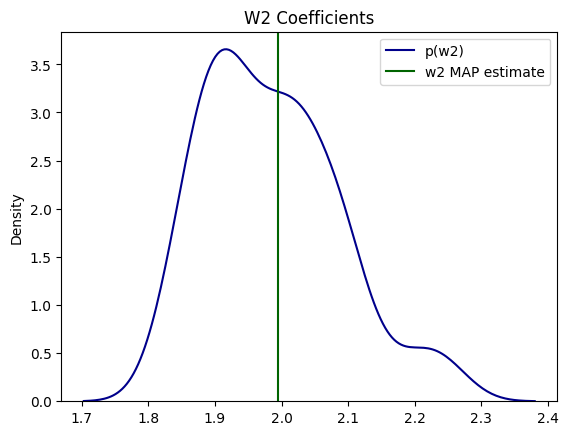

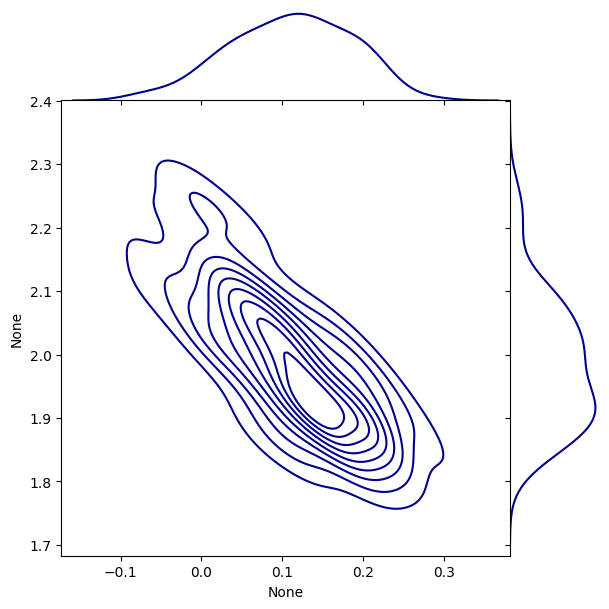

In [34]:
#We plot the sample distribution of the coefficients w1 and w2 separately as well as the MAP estimate
plt.figure()
plt.title("W1 Coefficients")
sns.distplot(LR_coefficient1, hist=False, color="darkblue", label = "p(w1)")
plt.axvline(LR_coefficient1[0], 0,1, color = "darkgreen", label="w1 MAP estimate")
plt.legend()

plt.figure()
plt.title("W2 Coefficients")
sns.distplot(LR_coefficient2, hist=False, color="darkblue", label = "p(w2)")
plt.axvline(LR_coefficient2[0], 0,1, color = "darkgreen", label="w2 MAP estimate")
plt.legend()

#We plot the joint distribution of the coefficients
sns.jointplot(x=LR_coefficient1, y=LR_coefficient2, kind="kde", space=0, color="darkblue")
plt.show()


## Finally we plot the predictive probability distributions of the ensemble for the points x1=[2,0.5] and x2=[3,0.5], as well as the Plug-in Approximation for the probability with MAP and the Bayesian Model Averaging probability

### Note that the x1 point's predictive probability distribution has a lower variance, due to the fact that its closer to the data.
### As we get more and more data, the bayesian model averaging probability and the plug in approximation will converge to the same point

MAP probability = 0.41179409773931686
Probability mean = 0.40820695351540626
Probability standard deviation = 0.027042865354449417


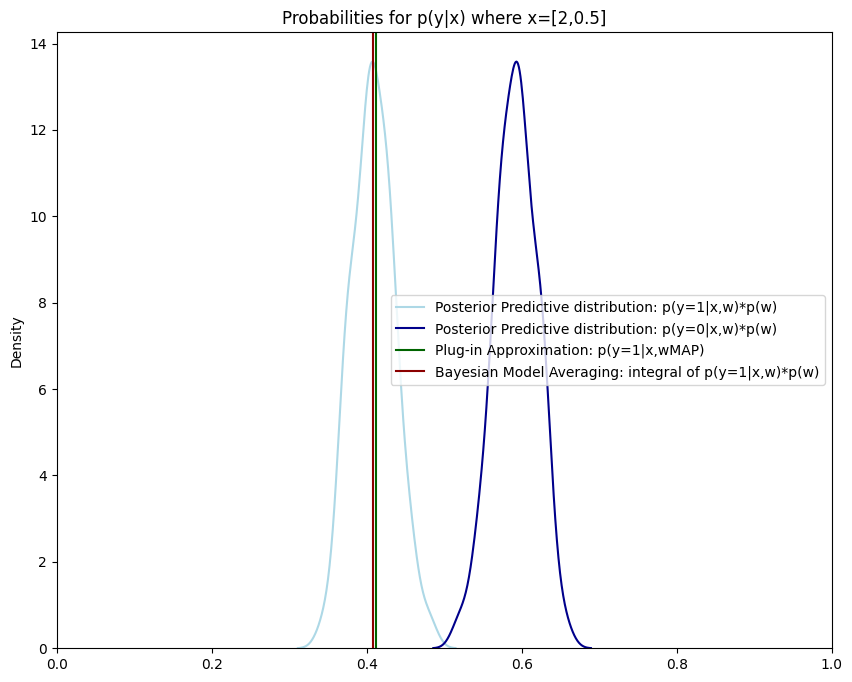

In [35]:
plt.figure(figsize=(10, 8), facecolor='white')
plt.xlim(0,1)
sns.distplot(PosPrediction_probabilities, hist=False, color="lightblue", label = "Posterior Predictive distribution: p(y=1|x,w)*p(w)")
sns.distplot(NegPrediction_probabilities, hist=False, color="darkblue", label = "Posterior Predictive distribution: p(y=0|x,w)*p(w)")
plt.axvline(PosPrediction_probabilities[0], 0,1, color = "darkgreen", label="Plug-in Approximation: p(y=1|x,wMAP)")
plt.axvline(np.mean(PosPrediction_probabilities), 0,1, color = "darkred", label="Bayesian Model Averaging: integral of p(y=1|x,w)*p(w)")
plt.legend()
plt.title("Probabilities for p(y|x) where x=[2,0.5]")
print("MAP probability =",PosPrediction_probabilities[0])
print("Probability mean =",np.mean(PosPrediction_probabilities))
print("Probability standard deviation =",np.std(PosPrediction_probabilities))

MAP probability = 0.38784211169603733
Probability mean = 0.3825683166912904
Probability standard deviation = 0.043238232584694766


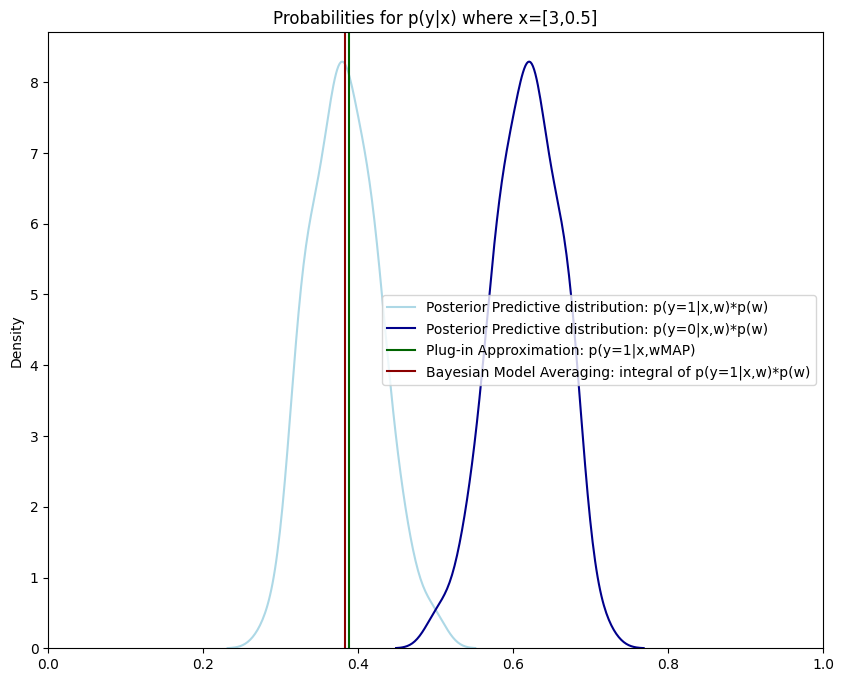

In [36]:
plt.figure(figsize=(10, 8), facecolor='white')
plt.xlim(0,1)
sns.distplot(PosPrediction_probabilities2, hist=False, color="lightblue", label = "Posterior Predictive distribution: p(y=1|x,w)*p(w)")
sns.distplot(NegPrediction_probabilities2, hist=False, color="darkblue", label = "Posterior Predictive distribution: p(y=0|x,w)*p(w)")
plt.axvline(PosPrediction_probabilities2[0], 0,1, color = "darkgreen", label="Plug-in Approximation: p(y=1|x,wMAP)")
plt.axvline(np.mean(PosPrediction_probabilities2), 0,1, color = "darkred", label="Bayesian Model Averaging: integral of p(y=1|x,w)*p(w)")
plt.legend()
plt.title("Probabilities for p(y|x) where x=[3,0.5]")

print("MAP probability =",PosPrediction_probabilities2[0])
print("Probability mean =",np.mean(PosPrediction_probabilities2))
print("Probability standard deviation =",np.std(PosPrediction_probabilities2))